In [2]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cftime

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import nc_time_axis 
#from scipy.stats import linregress

import intake_esgf
from intake_esgf import ESGFCatalog
import glob
from functools import partial
import pandas as pd


Info via https://wcrp-cmip.org/cmip-model-and-experiment-documentation/#cmip6-2
| Model | Aerosol | Atmos Chem|
| ----- | ------- | --------- |
| ACCESS-CM2 | UKCA-GLOMAP-mode (seven mode scheme) | none |
| CESM2 | MAM4 (same grid as atmos) | MAM4 (same grid as atmos) |
| E3SM-2-0 | MAM4 with new resuspension, marine organics, secondary organics, and dust (atmos grid) | Troposphere specified oxidants (except passive ozone with the lower boundary sink) for aerosols. Stratosphere linearized interactive ozone (LINOZ v2) (atmos grid) |
| GFDL-ESM4 | Bulk model | GFDL-ATMCHEM4.1 (full atmospheric chemistry) |
| GISS-E2-1-G | varies with physics-version (p==1 precomputed offline aerosol effects, p==3 OMA, p==4 TOMAS, p==5 MATRIX) | varies with physics-version (p==1 Non-interactive, p>1 GPUCCINI) |
| HadGEM3-GC31-LL  | UKCA-GLOMAP-mode (seven mode scheme) | none |


In [3]:
def _selBoundary(data):
    return data.sel(time=slice('1850-01-01', '2020-12-01'), lon=slice(360-90,360-65), lat=slice(25,50))

In [4]:
def importModelData(model_info):
    m = model_info
    data_dir = f'./{m.project}/{m.activity_drs}/{m.institution_id}/{m.source_id}/{m.experiment_id}/{m.member_id}/{m.table_id}/{m.variable_id}/{m.grid_label}/v{m.version}/'
    #print(data_dir)
    full_data_path = os.path.normpath(os.path.join(os.getcwd(), data_dir))
    print(full_data_path)
    data_files = sorted(glob.glob(f'{full_data_path}/*.nc'))
    #print(data_files)
    partial_func = partial(_selBoundary)
    ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
    return ds

In [60]:
cat = ESGFCatalog()

group_a = cat.search(
    activity_id="DAMIP",
    activity_drs="DAMIP",
    variable_id="ts",
    experiment_id=["hist-aer", "hist-nat"],
    source_id=['ACCESS-CM2', 'CESM2', 'E3SM-2-0', 'GFDL-ESM4',  'GISS-E2-1-G'], #'NorESM2-LM',
    member_id="r1i1p1f1", 
    table_id="Amon"
)
grpa_df = group_a.df

group_b = cat.search(
    activity_id="DAMIP",
    activity_drs="DAMIP",
    variable_id="ts",
    experiment_id=["hist-aer", "hist-nat"],
    source_id=['HadGEM3-GC31-LL'],
    member_id="r1i1p1f3", 
    table_id="Amon"
)

grpb_df = group_b.df

model_results = pd.concat([grpa_df, grpb_df], ignore_index=True)

   Searching indices:   0%|          |0/1 [       ?index/s]

   Searching indices:   0%|          |0/1 [       ?index/s]

In [61]:
model_results

,project,mip_era,activity_drs,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,version,id
0,CMIP6,CMIP6,DAMIP,CSIRO-ARCCSS,ACCESS-CM2,hist-aer,r1i1p1f1,Amon,ts,gn,20201120,[CMIP6.DAMIP.CSIRO-ARCCSS.ACCESS-CM2.hist-aer....
1,CMIP6,CMIP6,DAMIP,CSIRO-ARCCSS,ACCESS-CM2,hist-nat,r1i1p1f1,Amon,ts,gn,20201120,[CMIP6.DAMIP.CSIRO-ARCCSS.ACCESS-CM2.hist-nat....
2,CMIP6,CMIP6,DAMIP,E3SM-Project,E3SM-2-0,hist-aer,r1i1p1f1,Amon,ts,gr,20220905,[CMIP6.DAMIP.E3SM-Project.E3SM-2-0.hist-aer.r1...
3,CMIP6,CMIP6,DAMIP,E3SM-Project,E3SM-2-0,hist-nat,r1i1p1f1,Amon,ts,gr,20230104,[CMIP6.DAMIP.E3SM-Project.E3SM-2-0.hist-nat.r1...
4,CMIP6,CMIP6,DAMIP,NASA-GISS,GISS-E2-1-G,hist-aer,r1i1p1f1,Amon,ts,gn,20180821,[CMIP6.DAMIP.NASA-GISS.GISS-E2-1-G.hist-aer.r1...
5,CMIP6,CMIP6,DAMIP,NASA-GISS,GISS-E2-1-G,hist-nat,r1i1p1f1,Amon,ts,gn,20180906,[CMIP6.DAMIP.NASA-GISS.GISS-E2-1-G.hist-nat.r1...
6,CMIP6,CMIP6,DAMIP,NCAR,CESM2,hist-aer,r1i1p1f1,Amon,ts,gn,20200206,[CMIP6.DAMIP.NCAR.CESM2.hist-aer.r1i1p1f1.Amon...
7,CMIP6,CMIP6,DAMIP,NCAR,CESM2,hist-nat,r1i1p1f1,Amon,ts,gn,20190730,[CMIP6.DAMIP.NCAR.CESM2.hist-nat.r1i1p1f1.Amon...
8,CMIP6,CMIP6,DAMIP,NOAA-GFDL,GFDL-ESM4,hist-aer,r1i1p1f1,Amon,ts,gr1,20180701,[CMIP6.DAMIP.NOAA-GFDL.GFDL-ESM4.hist-aer.r1i1...
9,CMIP6,CMIP6,DAMIP,NOAA-GFDL,GFDL-ESM4,hist-nat,r1i1p1f1,Amon,ts,gr1,20180701,[CMIP6.DAMIP.NOAA-GFDL.GFDL-ESM4.hist-nat.r1i1...


In [62]:
datasets = {source_id: {} for source_id in model_results.source_id.unique()}
for i in model_results.index:
    model_info = model_results.loc[i, :]
    source_id = model_info.source_id

    # load historical aerosol only forcing
    if model_info.experiment_id == 'hist-aer':
        datasets[source_id]['hist-aer'] = importModelData(model_info)
    # load historical natural only forcing
    if model_info.experiment_id == 'hist-nat':
        datasets[source_id]['hist-nat'] = importModelData(model_info)

/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/CSIRO-ARCCSS/ACCESS-CM2/hist-aer/r1i1p1f1/Amon/ts/gn/v20201120


/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defau

/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/CSIRO-ARCCSS/ACCESS-CM2/hist-nat/r1i1p1f1/Amon/ts/gn/v20201120
/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/E3SM-Project/E3SM-2-0/hist-aer/r1i1p1f1/Amon/ts/gr/v20220905


/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defau

/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/E3SM-Project/E3SM-2-0/hist-nat/r1i1p1f1/Amon/ts/gr/v20230104
/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/NASA-GISS/GISS-E2-1-G/hist-aer/r1i1p1f1/Amon/ts/gn/v20180821


...

/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/NCAR/CESM2/hist-aer/r1i1p1f1/Amon/ts/gn/v20200206
/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/NCAR/CESM2/hist-nat/r1i1p1f1/Amon/ts/gn/v20190730


/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defau

/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/NOAA-GFDL/GFDL-ESM4/hist-aer/r1i1p1f1/Amon/ts/gr1/v20180701
/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/NOAA-GFDL/GFDL-ESM4/hist-nat/r1i1p1f1/Amon/ts/gr1/v20180701


/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset(data_files, concat_dim='time', combine='nested', preprocess=partial_func)
/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2746749630.py:10: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defau

/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/MOHC/HadGEM3-GC31-LL/hist-aer/r1i1p1f3/Amon/ts/gn/v20190814
/Users/sf20/Documents/Documents - atmos-sf20-mba22/ATMS 507 - Climate Dynamics/Group project/ATMS-507-Group-Project/CMIP6/DAMIP/MOHC/HadGEM3-GC31-LL/hist-nat/r1i1p1f3/Amon/ts/gn/v20190726


In [63]:
spatial_means = {}
for model in datasets.keys():
    spatial_means[model] = {}
    print(model)

    # Anthro aerosol forcing only
    aer_dat = datasets[model]['hist-aer']
    #aer_annual_dat = aer_dat.resample(time="YS").mean() # annual mean at each lat lon
    
    weights = np.cos(np.deg2rad(aer_dat.lat))
    weighted_dat = aer_dat['ts'].weighted(weights)
    weighted_mean = weighted_dat.mean(('lat', 'lon'))
    aer_annual_spatial_mean = weighted_mean.resample(time="YS").mean() # annual mean over all lat lon
    spatial_means[model]['hist-aer'] = aer_annual_spatial_mean

    # natural forcing only
    nat_dat = datasets[model]['hist-nat']
    #aer_annual_dat = aer_dat.resample(time="YS").mean() # annual mean at each lat lon
    weights = np.cos(np.deg2rad(nat_dat.lat))
    weighted_dat = nat_dat['ts'].weighted(weights)
    weighted_mean = weighted_dat.mean(('lat', 'lon'))
    nat_annual_spatial_mean = weighted_mean.resample(time="YS").mean() # annual mean over all lat lon
    spatial_means[model]['hist-nat'] = nat_annual_spatial_mean
    
# Compute bias between each model and the mean preindustrial temperature
# hist-nat pi biases
pi_nat_values = np.zeros((len(spatial_means.keys())))
for i, model in enumerate(spatial_means.keys()):
    pi_nat_values[i] = spatial_means[model]['hist-nat'].data[:10].mean() # use 1850-1860 mean as pi basis
pi_nat_mean = pi_nat_values.mean()
pi_nat_offsets = {}
for i, model in enumerate(spatial_means.keys()):
    pi_nat_offsets[model] = pi_nat_values[i] - pi_nat_mean

# hist-aer pi biases
pi_aer_values = np.zeros((len(spatial_means.keys())))
for i, model in enumerate(spatial_means.keys()):
    pi_aer_values[i] = spatial_means[model]['hist-aer'].data[:10].mean() # use 1850-1860 mean as pi basis
pi_aer_mean = pi_aer_values.mean()
pi_aer_offsets = {}
for i, model in enumerate(spatial_means.keys()):
    pi_aer_offsets[model] = pi_aer_values[i] - pi_aer_mean

ACCESS-CM2
E3SM-2-0
GISS-E2-1-G
CESM2
GFDL-ESM4
HadGEM3-GC31-LL


/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/2236615961.py:11: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(das_aligned, dim='model')


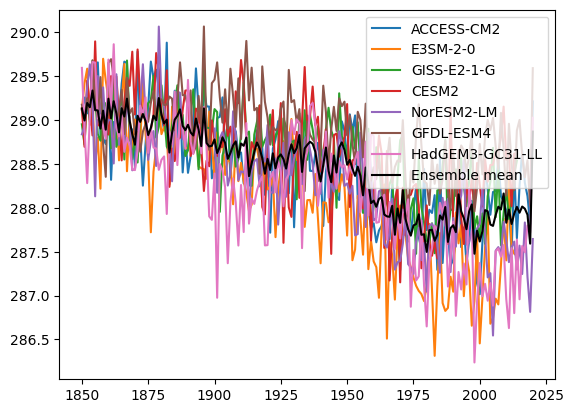

In [10]:
scenario = 'hist-aer'
fig, ax = plt.subplots(1,1)
for model in spatial_means.keys():
    aer_annual_spatial_mean = spatial_means[model][scenario]
    ax.plot(np.arange(aer_annual_spatial_mean.time.min().dt.year, 
                        aer_annual_spatial_mean.time.max().dt.year+1), 
                aer_annual_spatial_mean-pi_aer_offsets[model], label=model)

# calculate ensemble mean and plot
das_aligned = [da.convert_calendar('noleap', align_on='date') for da in [spatial_means[model][scenario]-pi_aer_offsets[model] for model in spatial_means.keys()]]
combined = xr.concat(das_aligned, dim='model')
ensemble_mean = combined.mean('model')

ax.plot(np.arange(ensemble_mean.time.min().dt.year, ensemble_mean.time.max().dt.year+1), ensemble_mean, c='k', label='Ensemble mean')
plt.legend(loc='upper right')

/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/1779843116.py:12: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(das_aligned, dim='model')


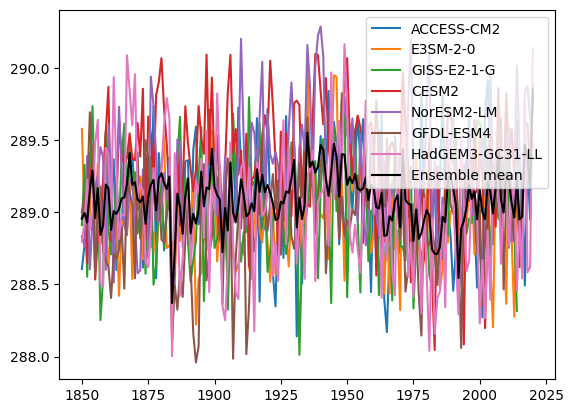

In [11]:
scenario = 'hist-nat'
fig, ax = plt.subplots(1,1)
for model in spatial_means.keys():
    aer_annual_spatial_mean = spatial_means[model][scenario]
    ax.plot(np.arange(aer_annual_spatial_mean.time.min().dt.year, 
                        aer_annual_spatial_mean.time.max().dt.year+1), 
                aer_annual_spatial_mean-pi_nat_offsets[model], label=model)


# calculate ensemble mean and plot
das_aligned = [da.convert_calendar('noleap', align_on='date') for da in [spatial_means[model][scenario]-pi_aer_offsets[model] for model in spatial_means.keys()]]
combined = xr.concat(das_aligned, dim='model')
ensemble_mean = combined.mean('model')

ax.plot(np.arange(ensemble_mean.time.min().dt.year, ensemble_mean.time.max().dt.year+1), ensemble_mean, c='k', label='Ensemble mean')
plt.legend(loc='upper right')

/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/3940427676.py:14: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(das_aligned, dim='model')
/var/folders/3p/g6j_y4hj63v0_klskdgcx7jm0000gr/T/ipykernel_9040/3940427676.py:34: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'time' ('time',) The recommendation is to set join explicitly for this case.
  combined = xr.concat(das_aligned, dim='model')


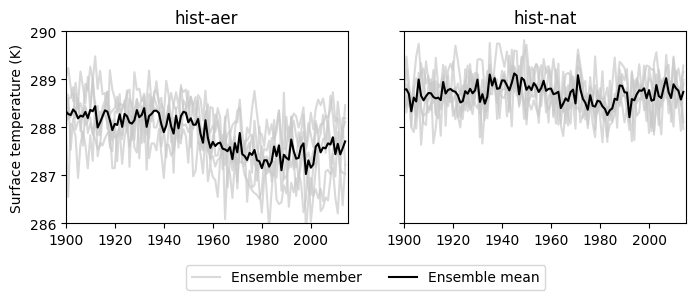

In [65]:
fig, axs = plt.subplots(1,2, figsize=(8, 3), sharey=True)
plt.subplots_adjust(bottom=.24,)
scenario = 'hist-aer'
ax=axs[0]
colors = plt.cm.Blues(np.linspace(.2,1,len(spatial_means.keys())))
for c, model in zip(colors, spatial_means.keys()):
    aer_annual_spatial_mean = spatial_means[model][scenario].sel(time=slice('1900-01-01', '2014-12-01'))
    ax.plot(np.arange(aer_annual_spatial_mean.time.min().dt.year, 
                        aer_annual_spatial_mean.time.max().dt.year+1), 
                aer_annual_spatial_mean-pi_aer_offsets[model], label=model, alpha=.7, color='#C9C9C9')

# calculate ensemble mean and plot
das_aligned = [da.convert_calendar('noleap', align_on='date') for da in [spatial_means[model][scenario]-pi_aer_offsets[model] for model in spatial_means.keys()]]
combined = xr.concat(das_aligned, dim='model')
aer_ensemble_mean = combined.mean('model').sel(time=slice('1900-01-01', '2014-12-01'))

ax.plot(np.arange(aer_ensemble_mean.time.min().dt.year, aer_ensemble_mean.time.max().dt.year+1), aer_ensemble_mean, c='k', label='Ensemble mean')
ax.set_ylabel('Surface temperature (K)')
ax.set_title('hist-aer')
ax.set_xlim(1900, 2015)

scenario = 'hist-nat'
ax=axs[1]
colors = plt.cm.Blues(np.linspace(.2,1,len(spatial_means.keys())))
for c, model in zip(colors, spatial_means.keys()):
    aer_annual_spatial_mean = spatial_means[model][scenario].sel(time=slice('1900-01-01', '2014-12-01'))
    ax.plot(np.arange(aer_annual_spatial_mean.time.min().dt.year, 
                        aer_annual_spatial_mean.time.max().dt.year+1), 
                aer_annual_spatial_mean-pi_nat_offsets[model], label=model, alpha=.7, color='#C9C9C9')


# calculate ensemble mean and plot
das_aligned = [da.convert_calendar('noleap', align_on='date') for da in [spatial_means[model][scenario]-pi_aer_offsets[model] for model in spatial_means.keys()]]
combined = xr.concat(das_aligned, dim='model')
nat_ensemble_mean = combined.mean('model').sel(time=slice('1900-01-01', '2014-12-01'))

ax.plot(np.arange(nat_ensemble_mean.time.min().dt.year, nat_ensemble_mean.time.max().dt.year+1), nat_ensemble_mean, c='k', label='Ensemble mean')
ax.set_ylim(286.,290.)
ax.set_xlim(1900, 2015)
ax.set_title('hist-nat')
handles, labels = ax.get_legend_handles_labels()
handles = handles[-2:]
labels = labels[-2:]
labels[0] = 'Ensemble member'

plt.legend(handles, labels, bbox_to_anchor=(0.5, .06), loc='center', ncol=2, bbox_transform=fig.transFigure)
plt.savefig('ts-timeseries-ensemble.png', format='png')

In [18]:
nat_ensemble_mean_ = nat_ensemble_mean.compute()
aer_ensemble_mean_ = aer_ensemble_mean.compute()

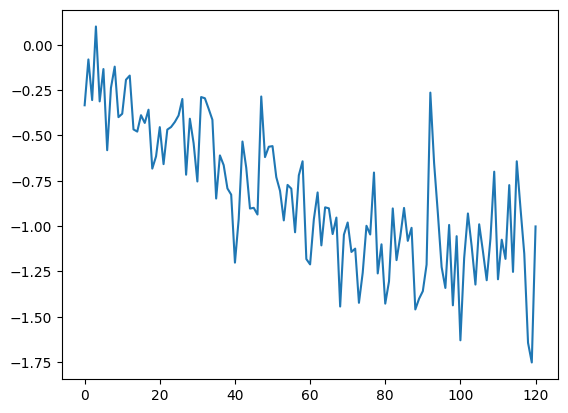

In [364]:
plt.plot(aer_ensemble_mean_-nat_ensemble_mean_)
#plt.plot(aer_ensemble_mean_)

In [70]:
def plotBiasTsAllModels():
    """Plot Bias in outgoing LW and SW TOA fluxes between 2010s and 1960s"""

    fig, axs = plt.subplots(len(datasets.keys()), 2, figsize=(5, 8), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    plt.subplots_adjust(left=0.27, right=1, wspace=0.01, hspace=0.04, bottom=0.12, top=.95)

    
    for i, source_id in enumerate(datasets.keys()):
        for j, experiment_id in enumerate(['hist-aer', 'hist-nat']):
            ax = axs[i,j]
            var = 'ts'

            dataset = datasets[source_id][experiment_id][var]
                
            # 1960-1969 mean for each grid cell (just before CAA)
            var60_mean = dataset.sel(time=slice("1960-01-01", "1969-12-01")).mean(axis=0)
            # 2010-2020 mean for each grid cell
            var10_mean = dataset.sel(time=slice("2010-01-01", "2020-12-01")).mean(axis=0)

            # compute bias between 2010s and 1960s 
            var_bias = var10_mean - var60_mean
            
            im = var_bias.plot.pcolormesh(
                ax=ax,
                x='lon', y='lat',
                transform=ccrs.PlateCarree(),
                cmap='coolwarm',
                vmin=-1.5, vmax=1.5,
                add_colorbar=False,  # disable individual colorbars
                edgecolors='none'
            )
            ax.add_feature(cfeature.STATES)
            ax.set_box_aspect(1)
        
        # Place model label to the left of the first column
        axs[i, 0].text(-0.22, 0.5, source_id, 
                        transform=axs[i, 0].transAxes,  va='center', ha='right', fontsize=10)

    axs[0, 0].set_title(f'Ts hist-aer', fontsize=10)
    axs[0, 1].set_title(f'Ts hist-nat', fontsize=10)

    # Add a single horizontal colorbar at the bottom
    cbar_left = axs[-1, 0].get_position().x0
    cbar_right= axs[-1, 1].get_position().x1

    cbar_ax = fig.add_axes([cbar_left, 0.07, cbar_right-cbar_left, 0.02])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Bias, 2010s - 1960s (K)')
    plt.savefig('ts-damip-eastern-us-bias.png', format='png')

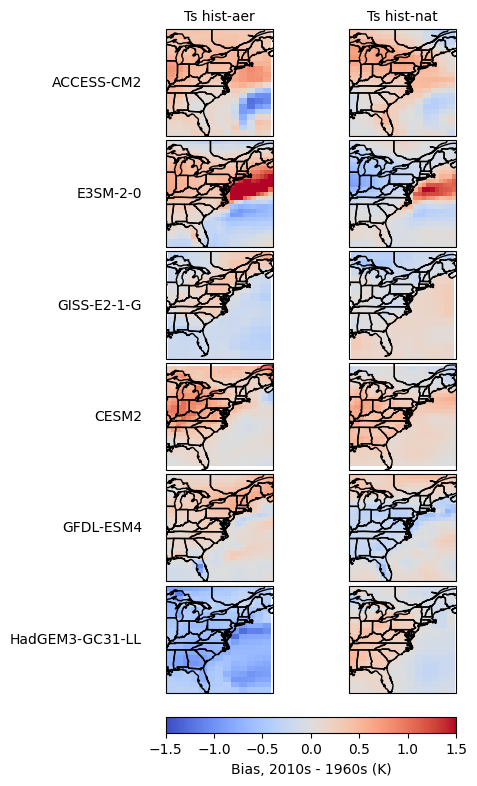

In [71]:
plotBiasTsAllModels()

In [94]:
def plotBiasTsSingleModel(source_id):
    """Plot Bias in outgoing LW and SW TOA fluxes between 2010s and 1960s"""

    fig, axs = plt.subplots(1, 2, figsize=(7, 3.5), 
                         subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    plt.subplots_adjust(left=0.2, right=.95, wspace=0.1, hspace=0.04, bottom=0.15, top=.95)

    for j, experiment_id in enumerate(['hist-aer', 'hist-nat']):
        ax = axs[j]
        var = 'ts'

        dataset = datasets[source_id][experiment_id][var]
            
        # 1960-1969 mean for each grid cell (just before CAA)
        var60_mean = dataset.sel(time=slice("1960-01-01", "1969-12-01")).mean(axis=0)
        # 2010-2020 mean for each grid cell
        var10_mean = dataset.sel(time=slice("2010-01-01", "2020-12-01")).mean(axis=0)

        # compute bias between 2010s and 1960s 
        var_bias = var10_mean - var60_mean
        
        im = var_bias.plot.pcolormesh(
            ax=ax,
            x='lon', y='lat',
            transform=ccrs.PlateCarree(),
            cmap='coolwarm',
            vmin=-1.5, vmax=1.5,
            add_colorbar=False,  # disable individual colorbars
            edgecolors='none'
        )
        ax.add_feature(cfeature.STATES)
        ax.set_box_aspect(1)
    
    # Place model label to the left of the first column
    axs[0].text(-0.22, 0.5, source_id, 
                    transform=axs[0].transAxes,  va='center', ha='right', fontsize=10)

    axs[0].set_title(f'Ts hist-aer', fontsize=10)
    axs[1].set_title(f'Ts hist-nat', fontsize=10)

    # Add a single horizontal colorbar at the bottom
    cbar_left = axs[0].get_position().x0
    cbar_right= axs[1].get_position().x1

    cbar_ax = fig.add_axes([cbar_left, 0.12, cbar_right-cbar_left, 0.03])  # [left, bottom, width, height]
    fig.colorbar(im, cax=cbar_ax, orientation='horizontal', label='Bias, 2010s - 1960s (K)')
    plt.savefig(f'{source_id}-ts-damip-eastern-us-bias.png', format='png')

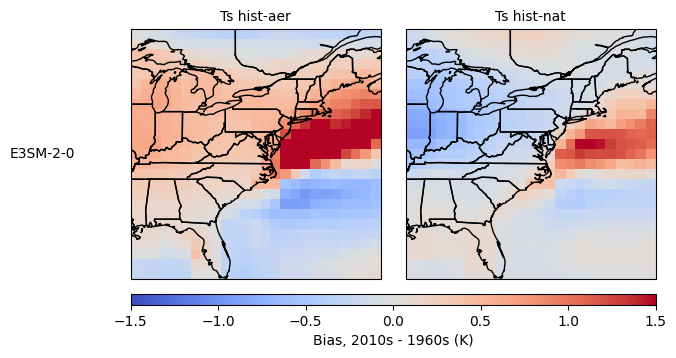

In [95]:
plotBiasTsSingleModel('E3SM-2-0')